- ## **Import Libraries:**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

- ## **Load Dataset churn_cleaned.csv**

In [2]:
df = pd.read_csv("../data/preprocessed/churn_cleaned.csv")

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (7043, 15)

Columns:
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label']

Missing values:
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
dtype: int64


## **Feature Engineering:**

In [13]:
print("Total Charges skewness: ",df["Total Charges"].skew())
print("Tenure Months skewness: ",df["Tenure Months"].skew())
print("Monthly Charges skewness: ",df["Monthly Charges"].skew())

Total Charges skewness:  0.963234654832277
Tenure Months skewness:  0.2395397495619829
Monthly Charges skewness:  -0.22052443394398033


- Here we can transform "Total Charges", but as i am using tree-based models we do not need it.

In [14]:
df["Avg Monthly Spend"] = (
    df["Total Charges"] /
    df["Tenure Months"].replace(0, 1)
)

In [15]:
print(df[
    ["Tenure Months", "Total Charges", "Avg Monthly Spend","Monthly Charges"]
].head())

   Tenure Months  Total Charges  Avg Monthly Spend  Monthly Charges
0              2         108.15          54.075000            53.85
1              2         151.65          75.825000            70.70
2              8         820.50         102.562500            99.65
3             28        3046.05         108.787500           104.80
4             49        5036.30         102.781633           103.70


- Correlation:

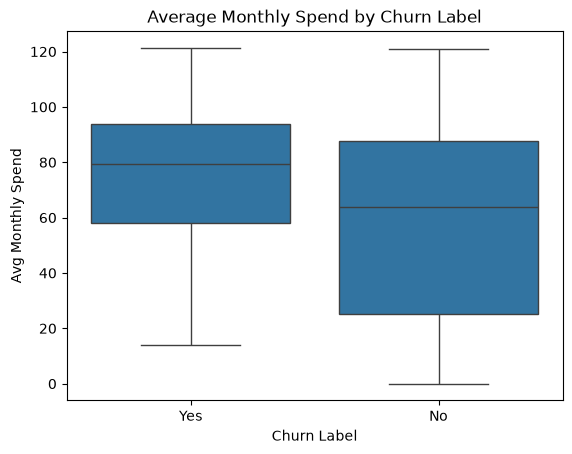

In [16]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Avg Monthly Spend"
)

plt.title("Average Monthly Spend by Churn Label")
plt.show()

In [17]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)
corr_matrix = numeric_df.corr(method="spearman")

print(corr_matrix)

                   Tenure Months  Monthly Charges  Total Charges  \
Tenure Months           1.000000         0.276417       0.889696   
Monthly Charges         0.276417         1.000000       0.638028   
Total Charges           0.889696         0.638028       1.000000   
Avg Monthly Spend       0.276405         0.990696       0.638850   

                   Avg Monthly Spend  
Tenure Months               0.276405  
Monthly Charges             0.990696  
Total Charges               0.638850  
Avg Monthly Spend           1.000000  


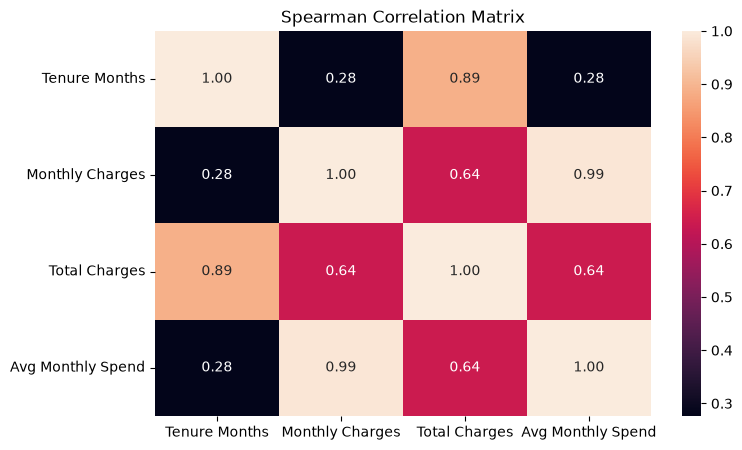

In [18]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix")
plt.show()

- Creating a temp variable churn and copy numeric feature to it, and let's analyse: How are our numerical features related to the thing we are trying to predict - churn?

In [19]:
corr_df = df.select_dtypes(include=["int64","float64"]).copy()

In [20]:
corr_df["churn"] = df["Churn Label"].map({
    "No":0,
    "Yes":1
})
corr_matrix = corr_df.corr(method="spearman")

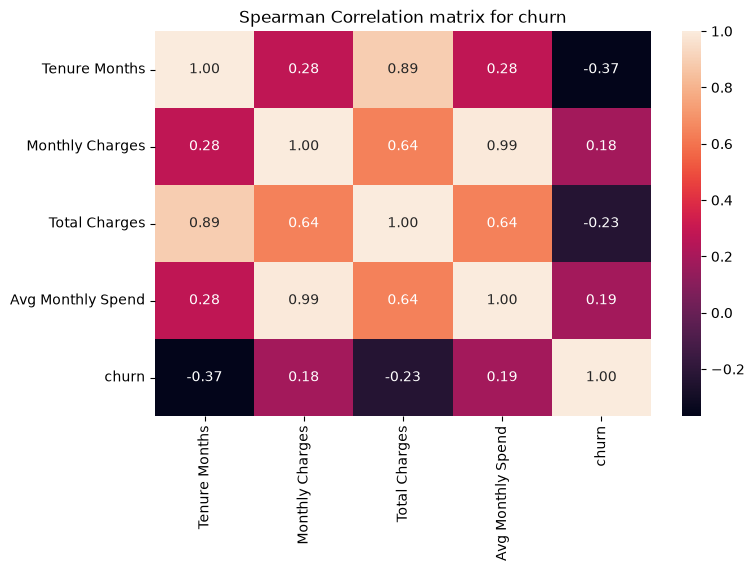

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt = ".2f"
)
plt.title("Spearman Correlation matrix for churn")
plt.show()

- Monthly Charges <=> Avg Monthly Spend = 0.99. So we drop Avg Monthly Spend column:


In [27]:
df = df.drop("Avg Monthly Spend",axis=1)

Seperate Features in x and y:

In [28]:
X = df.drop("Churn Label",axis=1)
Y = df["Churn Label"]

In [29]:
print("Shape of x: ",X.shape)
print("Shape of y: ",Y.shape)

print("\n X columns: ",X.columns.tolist())
print("\n Y Target values: ",Y.value_counts())

Shape of x:  (7043, 14)
Shape of y:  (7043,)

 X columns:  ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']

 Y Target values:  Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42,stratify=Y)

In [31]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test :", Y_test.shape)

X_train: (5634, 14)
X_test : (1409, 14)
y_train: (5634,)
y_test : (1409,)


In [32]:
print("\nTraining distribution:")
print(Y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(Y_test.value_counts(normalize=True) * 100)


Training distribution:
Churn Label
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

Testing distribution:
Churn Label
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64


In [33]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

## **Data Preprcessing**

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


- I can add SimpleImputer but the data do not have any missing values. Handle missing values when they actually exist, rather than adding an unnecessary preprocessing step.

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num','passthrough',numeric_features),
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ]
)

- ## **RandomForestClassifier:**

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
rf_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(
        random_state=42)
    )
])

In [38]:
rf_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Senior Citizen','Partner','Dependents',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [39]:
y_pred_rf = rf_pipeline.predict(X_test)

In [40]:
print(y_pred_rf[:20])

['No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No']


In [41]:
print("Number of predictions:", len(y_pred_rf))

Number of predictions: 1409


In [42]:
print(Y_test.head(20).values)

<StringArray>
[ 'No',  'No',  'No',  'No',  'No',  'No',  'No',  'No',  'No', 'Yes',  'No',
  'No',  'No', 'Yes',  'No',  'No',  'No',  'No',  'No',  'No']
Length: 20, dtype: str


## **Model Evaluation:**

- Let's check it's confusion matrics first:


In [43]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
cm_rf = confusion_matrix(Y_test, y_pred_rf)

print(cm_rf)

[[916 119]
 [183 191]]


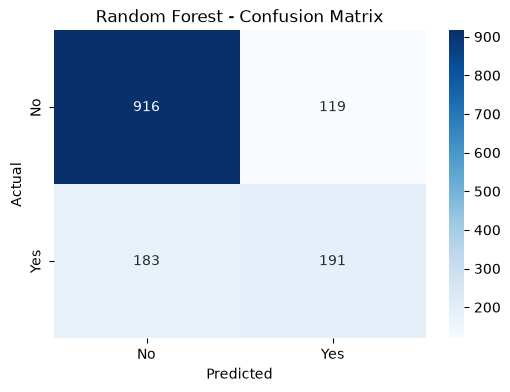

In [44]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

- TN: 916
- TP: 191
- FN: 183
- FP: 119

In [45]:
print("Accuracy: ",
      accuracy_score(Y_test, y_pred_rf))

print("Precision:",
      precision_score(Y_test, y_pred_rf, pos_label="Yes"))

print("Recall:   ",
      recall_score(Y_test, y_pred_rf, pos_label="Yes"))

print("F1-Score: ",
      f1_score(Y_test, y_pred_rf, pos_label="Yes"))

print("ROC-AUC:  ",
      roc_auc_score(
          (Y_test == "Yes").astype(int),
          rf_pipeline.predict_proba(X_test)[:, 1]
      ))

Accuracy:  0.7856635911994322
Precision: 0.6161290322580645
Recall:    0.5106951871657754
F1-Score:  0.5584795321637427
ROC-AUC:   0.8289984241390891


- ## **XGBoost Classifier:**

In [47]:
from xgboost import XGBClassifier

In [48]:
X = df.drop("Churn Label", axis=1)

Y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [49]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [50]:
print(Y_train.value_counts())
print(Y_test.value_counts())

Churn Label
0    4139
1    1495
Name: count, dtype: int64
Churn Label
0    1035
1     374
Name: count, dtype: int64


In [51]:

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [53]:

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb)
])

In [55]:
xgb_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Senior Citizen','Partner','Dependents',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [56]:
Y_pred_xgb = xgb_pipeline.predict(X_test)

In [57]:
cm_xgb = confusion_matrix(Y_test, Y_pred_xgb)

print(cm_xgb)

[[905 130]
 [174 200]]


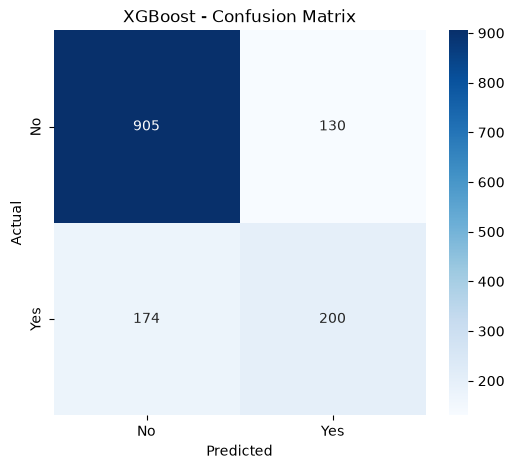

In [58]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")

plt.show()

In [61]:
print("Accuracy: ",
      accuracy_score(Y_test, Y_pred_xgb))

print("Precision:",
      precision_score(Y_test, Y_pred_xgb))

print("Recall:   ",
      recall_score(Y_test, Y_pred_xgb))

print("F1-Score: ",
      f1_score(Y_test, Y_pred_xgb))

print(
    "ROC-AUC: ", roc_auc_score
    (Y_test, 
    xgb_pipeline.predict_proba(X_test)[:, 1]))


Accuracy:  0.7842441447835344
Precision: 0.6060606060606061
Recall:    0.5347593582887701
F1-Score:  0.5681818181818182
ROC-AUC:  0.8313079645560464


## **Comparing Models: RF & XGBoost**

- Because the target variable is imbalanced, accuracy alone is not a reliable metric for model selection. We focus more on recall, F1-score, precision, and ROC-AUC, with recall being particularly important because the goal is to identify customers who are likely to churn.

**I compared Random Forest and XGBoost using the same train-test split and the same preprocessing pipeline. Since the churn classes were imbalanced, I didn't rely on accuracy alone. XGBoost achieved slightly better recall, F1-score, and ROC-AUC than Random Forest, which were more relevant to our objective of identifying potential churners. Random Forest had slightly higher precision and accuracy, but overall I selected XGBoost because it provided a better balance between identifying churners and maintaining precision. I then chose XGBoost for further hyperparameter tuning.**

HyperParameter Tuning:

In [62]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

In [63]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [64]:
grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about mul

In [65]:
print("Best parameters:")
print(grid_search.best_params_)
print("Best CV F1-score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
Best CV F1-score:
0.6165161713938756


In [66]:
best_xgb_model = grid_search.best_estimator_

In [67]:
print(best_xgb_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Senior Citizen', 'Partner',
                                                   'Dependents',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support', 'Contract',
                                   

In [68]:
Y_pred_xgb_tuned = best_xgb_model.predict(X_test)
Y_prob_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

In [70]:

cm_xgb_tuned = confusion_matrix(Y_test, Y_pred_xgb_tuned)
print(cm_xgb_tuned)

[[924 111]
 [168 206]]


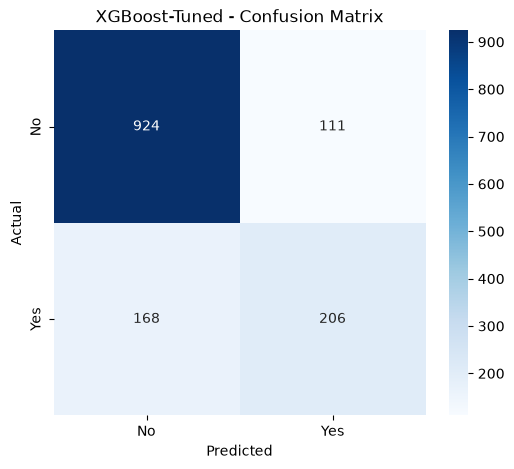

In [71]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost-Tuned - Confusion Matrix")

plt.show()

In [72]:
print("Accuracy: ", accuracy_score(Y_test, Y_pred_xgb_tuned))
print("Precision:", precision_score(Y_test, Y_pred_xgb_tuned))
print("Recall:   ", recall_score(Y_test, Y_pred_xgb_tuned))
print("F1-Score: ", f1_score(Y_test, Y_pred_xgb_tuned))
print("ROC-AUC:  ", roc_auc_score(Y_test, Y_prob_xgb_tuned))

Accuracy:  0.8019872249822569
Precision: 0.6498422712933754
Recall:    0.5508021390374331
F1-Score:  0.5962373371924746
ROC-AUC:   0.8534991862357592


In [77]:

comparison = pd.DataFrame({
    "RF Baseline": [
        0.7857,
        0.6161,
        0.5107,
        0.5585,
        0.8290
    ],
    "XGBoost Baseline": [
        0.7842,
        0.6061,
        0.5348,
        0.5682,
        0.8313
    ],
    "XGBoost Tuned": [
        0.8020,
        0.6498,
        0.5508,
        0.5962,
        0.8535
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
])

print(comparison)

           RF Baseline  XGBoost Baseline  XGBoost Tuned
Accuracy        0.7857            0.7842         0.8020
Precision       0.6161            0.6061         0.6498
Recall          0.5107            0.5348         0.5508
F1-Score        0.5585            0.5682         0.5962
ROC-AUC         0.8290            0.8313         0.8535


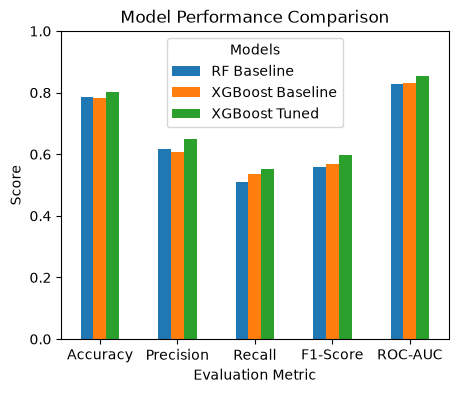

In [81]:
ax = comparison.plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Models")

plt.show()

- Threshold and Trade-off:

*Where should I put the decision boundary so that the model's behavior matches my objective?*

In [83]:

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:
    
    Y_pred_threshold = (Y_prob_xgb_tuned >= threshold).astype(int)
    
    precision = precision_score(Y_test, Y_pred_threshold)
    recall = recall_score(Y_test, Y_pred_threshold)
    f1 = f1_score(Y_test, Y_pred_threshold)
    
    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

   Threshold  Precision    Recall  F1-Score
0       0.30   0.529520  0.767380  0.626638
1       0.35   0.551724  0.727273  0.627451
2       0.40   0.594272  0.665775  0.627995
3       0.45   0.633880  0.620321  0.627027
4       0.50   0.649842  0.550802  0.596237
5       0.55   0.698039  0.475936  0.565978
6       0.60   0.734597  0.414439  0.529915


- **The threshold controls how easily a probability becomes a positive prediction; lowering it makes the model more willing to predict churn, usually increasing recall but decreasing precision, while increasing it does the opposite. We tune the threshold when the default 0.50 decision does not match the business objective.**

In [114]:
Y_pred_050 = (Y_prob_xgb_tuned >= 0.50).astype(int)
Y_pred_040 = (Y_prob_xgb_tuned >= 0.40).astype(int)

comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted_>=0.50": Y_pred_050,
    "Predicted_>0.40": Y_pred_040
})

comparison.sample(10)

,Actual,Predicted_>=0.50,Predicted_>0.40
955,0,0,0
742,0,0,0
191,0,1,1
256,0,0,0
807,0,0,0
1397,0,0,0
854,1,0,1
327,0,0,0
465,0,0,0
679,1,0,0


In [102]:

X_train_fit, X_val, Y_train_fit, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42,
    stratify=Y_train
)

In [122]:
best_params = {
    "classifier__colsample_bytree": 1.0,
    "classifier__learning_rate": 0.05,
    "classifier__max_depth": 3,
    "classifier__n_estimators": 300,
    "classifier__subsample": 1.0
}

In [123]:
xgb_final_candidate = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=300,
    subsample=1.0
)

In [124]:
xgb_final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_final_candidate)
])

In [125]:
xgb_final_pipeline.fit(
    X_train_fit,
    Y_train_fit
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Senior Citizen','Partner','Dependents',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [126]:
Y_val_prob = xgb_final_pipeline.predict_proba(X_val)[:, 1]

In [127]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:

    Y_val_pred = (Y_val_prob > threshold).astype(int)

    precision = precision_score(Y_val, Y_val_pred)
    recall = recall_score(Y_val, Y_val_pred)
    f1 = f1_score(Y_val, Y_val_pred)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_val_df = pd.DataFrame(results)

threshold_val_df

,Threshold,Precision,Recall,F1-Score
0,0.30,0.555819,0.782609,0.650000
1,0.35,0.597826,0.735786,0.659670
2,0.40,0.645455,0.712375,0.677266
3,0.45,0.664336,0.635452,0.649573
4,0.50,0.699187,0.575251,0.631193
5,0.55,0.717073,0.491639,0.583333
6,0.60,0.743750,0.397993,0.518519


In [128]:
xgb_final = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=300,
    subsample=1.0
)

final_xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_final)
])

In [129]:
final_xgb_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Senior Citizen','Partner','Dependents',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [130]:
Y_test_prob = final_xgb_pipeline.predict_proba(X_test)[:, 1]

In [131]:
Y_test_pred_final = (Y_test_prob > 0.40).astype(int)


In [132]:
print("Final Test Performance")
print("-----------------------")

print("Accuracy: ", accuracy_score(Y_test, Y_test_pred_final))
print("Precision:", precision_score(Y_test, Y_test_pred_final))
print("Recall:   ", recall_score(Y_test, Y_test_pred_final))
print("F1-Score: ", f1_score(Y_test, Y_test_pred_final))
print("ROC-AUC:  ", roc_auc_score(Y_test, Y_test_prob))

Final Test Performance
-----------------------
Accuracy:  0.7906316536550745
Precision: 0.594272076372315
Recall:    0.6657754010695187
F1-Score:  0.6279949558638083
ROC-AUC:   0.8534991862357592


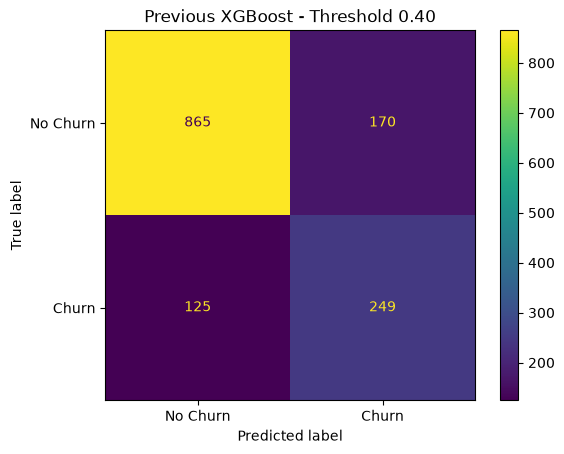

In [179]:
y_pred_old_040 = (Y_test_prob >= 0.40).astype(int)

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    y_pred_old_040,
    display_labels=["No Churn", "Churn"]
)

plt.title("Previous XGBoost - Threshold 0.40")
plt.show()

**Featuer Importance**

In [133]:
feature_names = final_xgb_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_names

array(['num__Tenure Months', 'num__Monthly Charges', 'num__Total Charges',
       'cat__Senior Citizen_No', 'cat__Senior Citizen_Yes',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__Internet Service_DSL',
       'cat__Internet Service_Fiber optic', 'cat__Internet Service_No',
       'cat__Online Security_No', 'cat__Online Security_Yes',
       'cat__Online Backup_No', 'cat__Online Backup_Yes',
       'cat__Device Protection_No', 'cat__Device Protection_Yes',
       'cat__Tech Support_No', 'cat__Tech Support_Yes',
       'cat__Contract_Month-to-month', 'cat__Contract_One year',
       'cat__Contract_Two year', 'cat__Paperless Billing_No',
       'cat__Paperless Billing_Yes',
       'cat__Payment Method_Bank transfer (automatic)',
       'cat__Payment Method_Credit card (automatic)',
       'cat__Payment Method_Electronic check',
       'cat__Payment Method_Mailed check'], dtype=object)

In [134]:
importances = final_xgb_pipeline.named_steps[
    "classifier"
].feature_importances_

In [135]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
20,cat__Contract_Month-to-month,0.294515
10,cat__Internet Service_Fiber optic,0.236519
11,cat__Internet Service_No,0.076637
27,cat__Payment Method_Electronic check,0.073682
7,cat__Dependents_No,0.071798
22,cat__Contract_Two year,0.061141
0,num__Tenure Months,0.027880
23,cat__Paperless Billing_No,0.024364
21,cat__Contract_One year,0.022406
12,cat__Online Security_No,0.020743


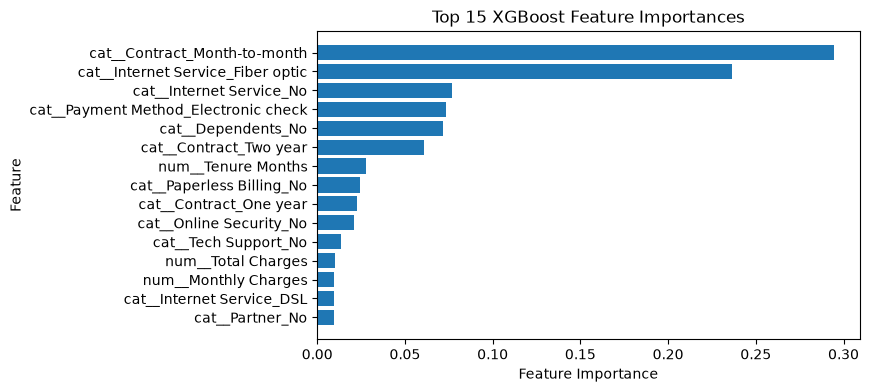

In [138]:

top_features = feature_importance_df.head(15)

plt.figure(figsize=(7, 4))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.show()

Observation: The model is relying heavily on contract type, particularly the month-to-month category.
This makes practical sense: customers without a long-term commitment may be more likely to leave.

**Error Analysis:**

In [139]:
error_df = X_test.copy()

error_df["Actual"] = Y_test
error_df["Churn Probability"] = Y_test_prob
error_df["Predicted"] = Y_test_pred_final

error_df.head()

,Senior Citizen,Partner,Dependents,Tenure Months,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual,Churn Probability,Predicted
2196,No,Yes,No,72,Fiber optic,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.037254,0
3549,Yes,No,No,8,Fiber optic,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.765615,1
3515,No,Yes,No,41,DSL,Yes,Yes,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.128126,0
5162,No,Yes,No,18,Fiber optic,No,No,Yes,Yes,Month-to-month,No,Electronic check,78.20,1468.75,0,0.502720,1
4642,No,Yes,No,72,DSL,Yes,Yes,Yes,No,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.007462,0


In [140]:
error_df["Result"] = "Correct"

error_df.loc[
    (error_df["Actual"] == 1) & (error_df["Predicted"] == 1),
    "Result"
] = "True Positive"

error_df.loc[
    (error_df["Actual"] == 0) & (error_df["Predicted"] == 0),
    "Result"
] = "True Negative"

error_df.loc[
    (error_df["Actual"] == 0) & (error_df["Predicted"] == 1),
    "Result"
] = "False Positive"

error_df.loc[
    (error_df["Actual"] == 1) & (error_df["Predicted"] == 0),
    "Result"
] = "False Negative"

In [141]:
error_df["Result"].value_counts()

Result
True Negative     865
True Positive     249
False Positive    170
False Negative    125
Name: count, dtype: int64

In [142]:
false_negatives = error_df[
    error_df["Result"] == "False Negative"
]

false_negatives.head()

,Senior Citizen,Partner,Dependents,Tenure Months,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual,Churn Probability,Predicted,Result
648,No,No,No,31,DSL,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,55.25,1715.65,1,0.240602,0,False Negative
134,No,No,No,23,Fiber optic,No,No,No,No,Month-to-month,No,Bank transfer (automatic),75.60,1758.60,1,0.260094,0,False Negative
1334,No,No,No,45,No,No,No,No,No,One year,Yes,Electronic check,20.40,930.45,1,0.028310,0,False Negative
891,No,No,No,4,DSL,No,Yes,No,No,Month-to-month,No,Credit card (automatic),50.70,151.30,1,0.333286,0,False Negative
1862,No,No,No,4,DSL,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,60.40,272.15,1,0.236372,0,False Negative


In [144]:
false_negatives[
    ["Churn Probability", "Actual", "Predicted"]
].sort_values(
    "Churn Probability",
    ascending=False
).head(16)

,Churn Probability,Actual,Predicted
1086,0.397633,1,0
848,0.397405,1,0
1169,0.392532,1,0
605,0.391613,1,0
1475,0.389665,1,0
383,0.389138,1,0
1685,0.388981,1,0
1471,0.388003,1,0
1237,0.387485,1,0
1620,0.386097,1,0


Observation: 
So these customers are extremely close to the decision boundary which is 0.40(Threshold)

In [146]:
false_negatives[
    [
        "Contract",
        "Internet Service",
        "Payment Method",
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "Churn Probability"
    ]
].sort_values(
    "Churn Probability",
    ascending=False
).head(15)

,Contract,Internet Service,Payment Method,Tenure Months,Monthly Charges,Total Charges,Churn Probability
1086,Month-to-month,DSL,Electronic check,13,23.90,300.80,0.397633
848,Month-to-month,Fiber optic,Bank transfer (automatic),37,106.75,4056.75,0.397405
1169,Month-to-month,Fiber optic,Bank transfer (automatic),12,81.70,858.60,0.392532
605,Month-to-month,DSL,Bank transfer (automatic),13,48.75,633.40,0.391613
1475,Month-to-month,Fiber optic,Bank transfer (automatic),22,90.50,1910.60,0.389665
383,Month-to-month,No,Electronic check,1,20.55,20.55,0.389138
1685,Month-to-month,DSL,Mailed check,1,44.65,44.65,0.388981
1471,Month-to-month,No,Mailed check,1,19.30,19.30,0.388003
1237,Month-to-month,DSL,Mailed check,1,62.05,62.05,0.387485
1620,Month-to-month,DSL,Electronic check,42,50.25,2203.65,0.386097


In [147]:
print("FALSE NEGATIVES")
print(false_negatives["Contract"].value_counts(normalize=True))

print("\nTRUE POSITIVES")
true_positives = error_df[
    error_df["Result"] == "True Positive"
]

print(true_positives["Contract"].value_counts(normalize=True))

FALSE NEGATIVES
Contract
Month-to-month    0.656
One year          0.272
Two year          0.072
Name: proportion, dtype: float64

TRUE POSITIVES
Contract
Month-to-month    0.991968
One year          0.008032
Name: proportion, dtype: float64


Observation: The model is very good at identifying churners who are on month-to-month contracts, but it is missing many churners who have longer-term contracts.

In [148]:
print("FALSE NEGATIVES")
print(false_negatives["Internet Service"].value_counts(normalize=True))

print("\nTRUE POSITIVES")
print(true_positives["Internet Service"].value_counts(normalize=True))

FALSE NEGATIVES
Internet Service
DSL            0.424
Fiber optic    0.408
No             0.168
Name: proportion, dtype: float64

TRUE POSITIVES
Internet Service
Fiber optic    0.807229
DSL            0.176707
No             0.016064
Name: proportion, dtype: float64


Observation: The model is very successful at identifying churners who are
Fiber optic,
But among the churners it misses, we see much more
DSL
No Internet

In [149]:
print("FALSE NEGATIVES")
print(false_negatives["Payment Method"].value_counts(normalize=True))

print("\nTRUE POSITIVES")
print(true_positives["Payment Method"].value_counts(normalize=True))

FALSE NEGATIVES
Payment Method
Electronic check             0.288
Mailed check                 0.264
Bank transfer (automatic)    0.232
Credit card (automatic)      0.216
Name: proportion, dtype: float64

TRUE POSITIVES
Payment Method
Electronic check             0.682731
Bank transfer (automatic)    0.112450
Mailed check                 0.108434
Credit card (automatic)      0.096386
Name: proportion, dtype: float64


Observation: The model is particularly good at identifying churners using
Electronic check,
But the churners it misses are much more diverse in their payment methods.

In [150]:
comparison = pd.DataFrame({
    "False Negatives": false_negatives[
        ["Tenure Months", "Monthly Charges", "Total Charges"]
    ].mean(),

    "True Positives": true_positives[
        ["Tenure Months", "Monthly Charges", "Total Charges"]
    ].mean()
})

comparison

,False Negatives,True Positives
Tenure Months,27.3440,11.000000
Monthly Charges,65.7008,76.314458
Total Charges,2267.7168,965.475502


Observation: 
False Negatives have much higher tenure,
But their monthly charges are actually lower.

In [151]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, float("inf")],
    labels=["0-12", "13-24", "25-48", "49+"]
)

In [152]:
df.groupby("Tenure Group")["Churn Label"].value_counts(normalize=True)

Tenure Group  Churn Label
0-12          No             0.525618
              Yes            0.474382
13-24         No             0.712891
              Yes            0.287109
25-48         No             0.796110
              Yes            0.203890
49+           No             0.904868
              Yes            0.095132
Name: proportion, dtype: float64

Observation: Customers with shorter tenure are much more likely to churn, while long-tenure customers are much less likely to churn.
I would add this group as a feature.


In [153]:
df[["Tenure Months", "Tenure Group"]].head(10)

,Tenure Months,Tenure Group
0,2,0-12
1,2,0-12
2,8,0-12
3,28,25-48
4,49,49+
5,10,0-12
6,1,0-12
7,1,0-12
8,47,25-48
9,1,0-12


In [154]:
df[["Tenure Months", "Tenure Group"]].head(10)

,Tenure Months,Tenure Group
0,2,0-12
1,2,0-12
2,8,0-12
3,28,25-48
4,49,49+
5,10,0-12
6,1,0-12
7,1,0-12
8,47,25-48
9,1,0-12


In [ ]:
categorical_cols = [
    "Tenure Group"
]

In [162]:
categorical_cols =[
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 "Tenure Group"
    ]

In [167]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

In [168]:
X = df.drop("Churn Label", axis=1)

Y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [169]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [170]:
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [171]:
xgb_tenure = XGBClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=300,
    colsample_bytree=1.0,
    subsample=1.0,
    random_state=42,
    eval_metric="logloss"
)

In [172]:
xgb_tenure_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_tenure)
])

In [173]:
xgb_tenure_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Senior Citizen','Partner','Dependents',...,'Monthly Charges', 'Total Charges','Tenure Group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [174]:
Y_prob_tenure = xgb_tenure_pipeline.predict_proba(X_test)[:, 1]

In [175]:
Y_pred_tenure = (Y_prob_tenure >= 0.40).astype(int)

In [176]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_tenure))
print("Precision:", precision_score(Y_test, Y_pred_tenure))
print("Recall:", recall_score(Y_test, Y_pred_tenure))
print("F1-Score:", f1_score(Y_test, Y_pred_tenure))
print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_tenure))

Accuracy: 0.7934705464868701
Precision: 0.5990453460620525
Recall: 0.6711229946524064
F1-Score: 0.6330390920554855
ROC-AUC: 0.8540068201193521


Observation: So Tenure Group gives the model a small but consistent improvement.

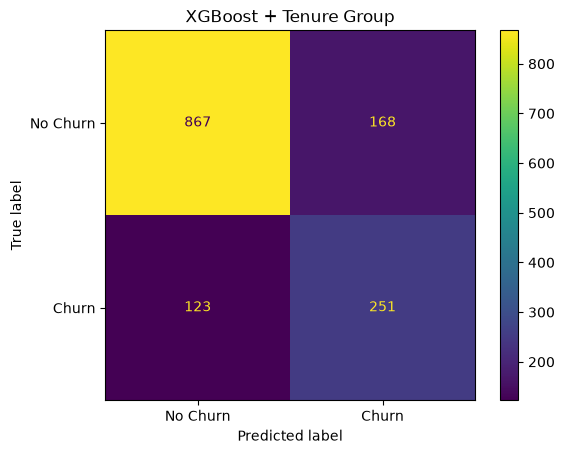

In [177]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    Y_pred_tenure,
    display_labels=["No Churn", "Churn"]
)

plt.title("XGBoost + Tenure Group")
plt.show()

In [178]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    Y_test,
    Y_pred_tenure
).ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 867
False Positive: 168
False Negative: 123
True Positive : 251


In [180]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:
    y_pred = (Y_prob_tenure >= threshold).astype(int)

    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.30,0.527675,0.764706,0.624454
1,0.35,0.557143,0.729947,0.631944
2,0.40,0.599045,0.671123,0.633039
3,0.45,0.634615,0.617647,0.626016
4,0.50,0.652866,0.548128,0.595930
5,0.55,0.698039,0.475936,0.565978
6,0.60,0.732057,0.409091,0.524871


In [181]:
best_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

best_row

Threshold    0.400000
Precision    0.599045
Recall       0.671123
F1-Score     0.633039
Name: 2, dtype: float64

## **Model Selection:**

Model: Tuned XGBoost

Feature: Tenure Group included

Threshold: 0.40

F1: 0.633

Recall: 0.671

ROC-AUC: 0.854